In [1]:
import os
os.chdir(r'C:\Users\user\Documents\supply_chain_analysis')


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings 
import seaborn as sns  
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
df = pd.read_csv('data/cleaned/supply_chain_cleaned.csv', encoding='latin-1')
print("Shape:", df.shape)
df.head()

Shape: (180519, 51)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,delivery_delay_days
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,COMPLETE,NaN,1360,73,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,3
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,PENDING,NaN,1360,73,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,5
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,CLOSED,NaN,1360,73,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class,4
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,COMPLETE,NaN,1360,73,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class,3
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,PENDING_PAYMENT,NaN,1360,73,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class,2


In [4]:
print("=== Dataset Summary ===")
print(f"Total Orders: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")
print(f"Date Range: {df['order date (DateOrders)'].min()} to {df['order date (DateOrders)'].max()}")
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Average Delivery Delay: {df['delivery_delay_days'].mean():.1f} days")

=== Dataset Summary ===
Total Orders: 180,519
Total Columns: 51
Date Range: 2015-01-01 00:00:00 to 2018-01-31 23:38:00
Total Sales: $36,784,735.01
Average Delivery Delay: 3.5 days


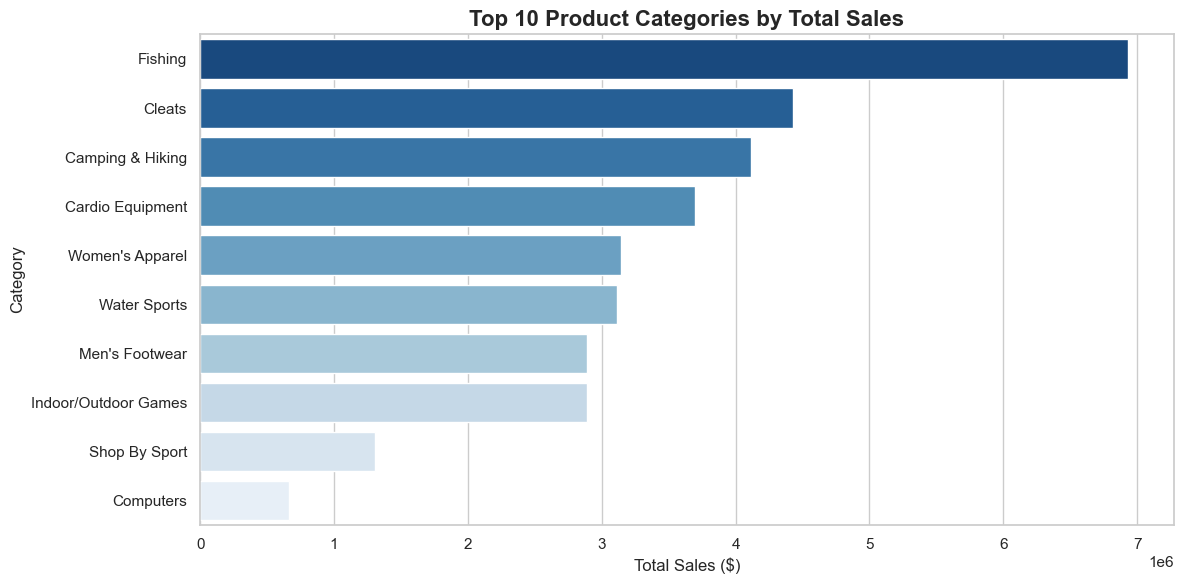

Chart 1 saved!


In [5]:
plt.figure(figsize=(12,6))
category_sales = df.groupby('Category Name')['Sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=category_sales.values, y=category_sales.index, palette='Blues_r')
plt.title('Top 10 Product Categories by Total Sales', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('visuals/chart1_sales_by_category.png', dpi=150)
plt.show()
print("Chart 1 saved!")

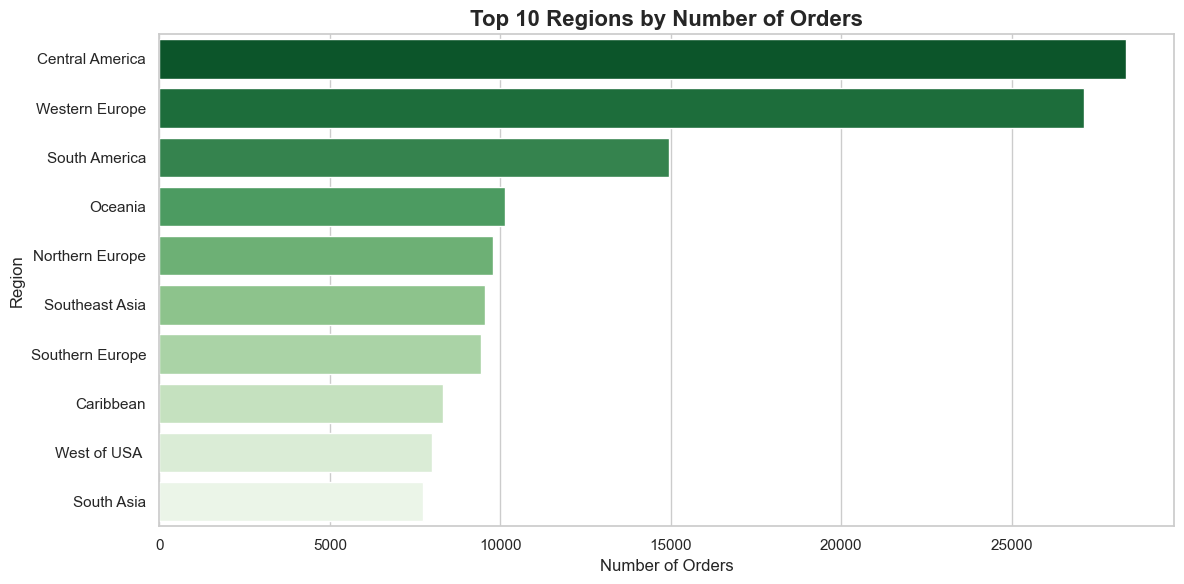

Chart 2 saved!


In [6]:
plt.figure(figsize=(12,6))
region_orders = df['Order Region'].value_counts().head(10)
sns.barplot(x=region_orders.values, y=region_orders.index, palette='Greens_r')
plt.title('Top 10 Regions by Number of Orders', fontsize=16, fontweight='bold')
plt.xlabel('Number of Orders')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig('visuals/chart2_orders_by_region.png', dpi=150)
plt.show()
print("Chart 2 saved!")

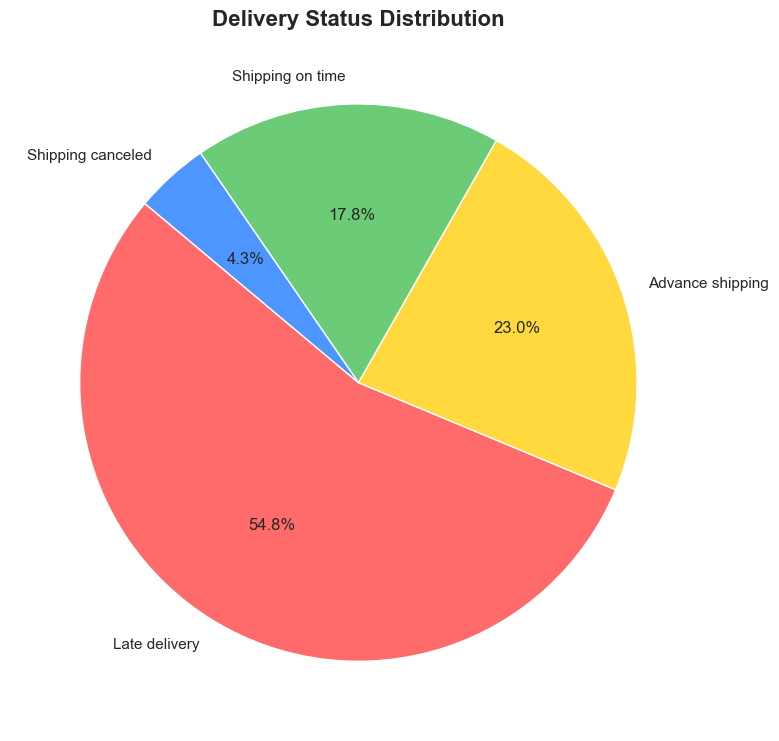

Chart 3 saved!


In [7]:
plt.figure(figsize=(8,8))
status_counts = df['Delivery Status'].value_counts()
colors = ['#ff6b6b','#ffd93d','#6bcb77','#4d96ff']
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=140)
plt.title('Delivery Status Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/chart3_delivery_status.png', dpi=150)
plt.show()
print("Chart 3 saved!")

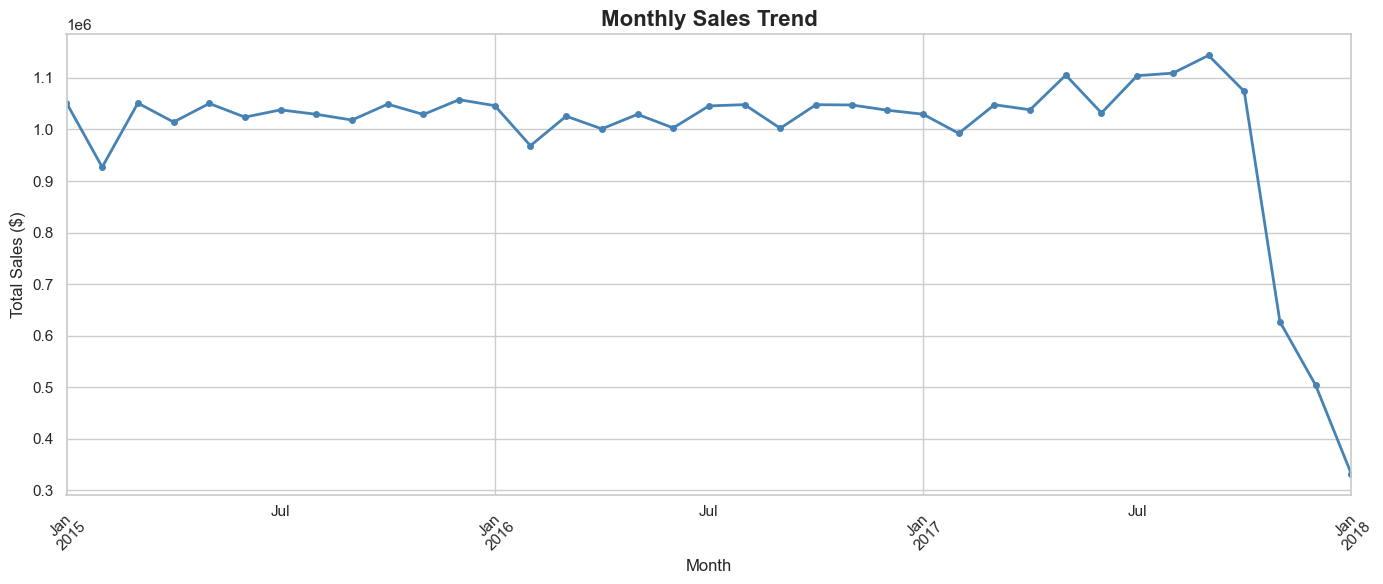

Chart 4 saved!


In [8]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['order_month'] = df['order date (DateOrders)'].dt.to_period('M')
monthly_sales = df.groupby('order_month')['Sales'].sum()

plt.figure(figsize=(14,6))
monthly_sales.plot(kind='line', color='steelblue', linewidth=2, marker='o', markersize=4)
plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visuals/chart4_monthly_sales_trend.png', dpi=150)
plt.show()
print("Chart 4 saved!")

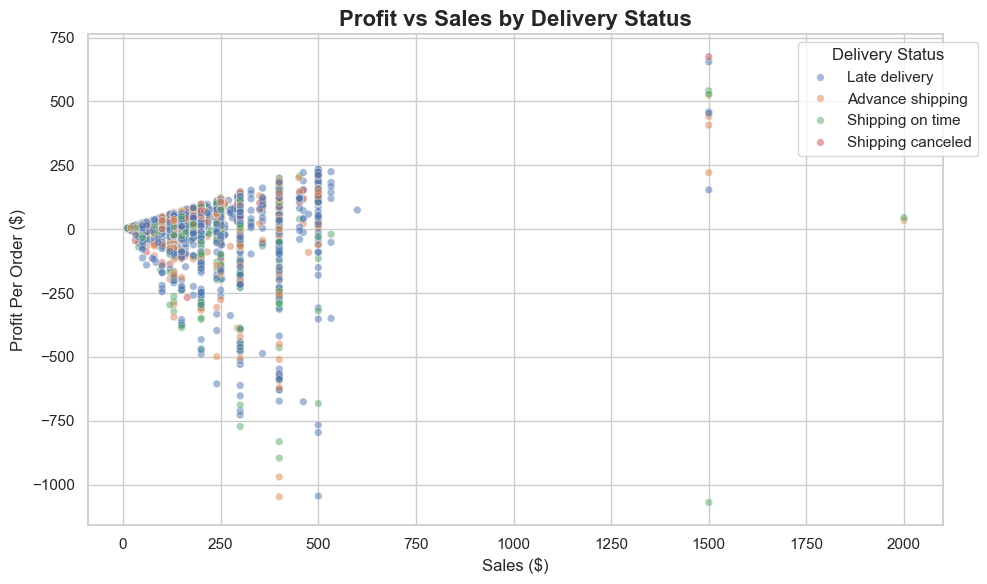

Chart 5 saved!


In [9]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df.sample(5000, random_state=42),
                x='Sales', y='Order Profit Per Order',
                hue='Delivery Status', alpha=0.5, s=30)
plt.title('Profit vs Sales by Delivery Status', fontsize=16, fontweight='bold')
plt.xlabel('Sales ($)')
plt.ylabel('Profit Per Order ($)')
plt.legend(title='Delivery Status', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('visuals/chart5_profit_vs_sales.png', dpi=150)
plt.show()
print("Chart 5 saved!")

In [10]:
print("Charts saved in visuals folder:")
for f in os.listdir('visuals/'):
    print(" Done", f)

Charts saved in visuals folder:
 Done chart1_sales_by_category.png
 Done chart2_orders_by_region.png
 Done chart3_delivery_status.png
 Done chart4_monthly_sales_trend.png
 Done chart5_profit_vs_sales.png
